# Лабораторна робота 2  
## Метрики оцінювання моделей машинного навчання та їх вплив на вибір моделі  
### Мета роботи

В цій лабораторній роботі вам необхідно дослідити, як вибір метрики оцінювання впливає на процес навчання та відбору моделей машинного навчання.  
У ході роботи необхідно порівняти результати навчання моделей при використанні різних метрик якості та проаналізувати отримані результати з точки зору практичних задач.  

Метрика може використовуватися не лише для оцінювання моделі, але й для оптимізації під час підбору параметрів.  Наприклад, метод GridSearchCV дозволяє знайти найкращу модель відповідно до обраної метрики. У такому випадку різні метрики можуть призвести до вибору різних моделей.

### Завдання 1. Вибір метрики у задачі класифікації

Банк розробляє модель для прогнозування ймовірності дефолту клієнтів за кредитами. Модель повинна передбачити, чи поверне клієнт отриманий кредит.  
У такій задачі можливі два типи помилок:

- False Negative - модель вважає клієнта надійним, але він не повертає кредит;  
- False Positive - модель відхиляє клієнта, який насправді міг би повернути кредит.  

Для виконання завдання використовуйте набір даних `Default of Credit Card Clients` (код для завантаження даних залишила під описом завдання).  
Цей набір даних містить інформацію про клієнтів банку та характеристики їхніх кредитів.  
Цільовою змінною є `class`, яка показує результат повернення кредиту:

- good - кредит було повернуто;  
- bad - клієнт не повернув кредит (дефолт).  

#### Завдання

1. Завантажте набір даних.  
2. Виділіть ознаки та цільову змінну.  
3. Розділіть дані на навчальну та тестову вибірки.  
4. Побудуйте модель класифікації (обираєте будь-який алгоритм).  
5. Проведіть чотири окремих запуски GridSearchCV, кожного разу використовуючи іншу метрику оцінювання:  
   - `accuracy`  
   - `precision`  
   - `recall`  
   - `f1`  
7. Для кожної метрики:  
   - визначте найкращі параметри моделі;  
   - побудуйте модель з цими параметрами;   
   - обчисліть метрики на тестовій вибірці;  
   - виведіть матрицю помилок та звіт про ккласифікацію.  
8. Порівняйте результати.

In [18]:
from sklearn.datasets import fetch_openml
data = fetch_openml(name="credit-g", version=1, as_frame=True)
df = data.frame
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


### Завдання 2  

Агентство нерухомості розробляє модель для прогнозування вартості житла.  
При оцінюванні якості моделі можуть використовуватися різні метрики:    
- MAE характеризує середню величину помилки прогнозу;  
- RMSE сильніше враховує великі помилки;  
- R² показує, яку частку варіації даних пояснює модель.  
Вибір метрики може вплинути на те, яка модель буде визнана найкращою.  

Для виконання завдання завантажте набір даних `California Housing` (код для завантаження залишила під описом завдання), який містить інформацію про характеристики житлових районів у Каліфорнії.  

Цільовою змінною є `MedHouseVal` - медіанна вартість житла у відповідному районі.  

#### Завдання

1. Завантажте набір даних.  
2. Підготуйте дані:  
   - виділіть ознаки та цільову змінну;  
   - розділіть дані на навчальну та тестову вибірки.  
3. Побудуйте модель регресії (алгоритм обираєте будь-який).  
4. Проведіть три окремі запуски GridSearchCV, кожного разу використовуючи іншу метрику оцінювання:  
   - `neg_mean_absolute_error`  
   - `neg_root_mean_squared_error`  
   - `r2`  

6. Для кожної метрики:  
   - визначте найкращі параметри моделі;  
   - навчіть модель з цими параметрами;  
   - обчисліть MAE, RMSE та R² на тестовій вибірці.  

7. Порівняйте результати.  

In [19]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
# Завантаження набору даних
data = fetch_california_housing(as_frame=True)
df = data.frame

# Перегляд перших рядків
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [20]:
from sklearn.model_selection import train_test_split

# Ознаки та цільова змінна
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Розбиття даних
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Створення моделей
lin_reg = LinearRegression()
dec_tree_reg = DecisionTreeRegressor(random_state=42)
rand_forest_reg = RandomForestRegressor(random_state=42)

# Навчання моделей
lin_reg.fit(X_train, y_train)
dec_tree_reg.fit(X_train, y_train)
rand_forest_reg.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

reg_models = {
    'Linear Regression': lin_reg,
    'Decision Tree': dec_tree_reg,
    'Random Forest': rand_forest_reg
}

reg_results = []

for name, model in reg_models.items():
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    reg_results.append([
        name,
        mae,
        rmse,
        r2
    ])

reg_results_df = pd.DataFrame(
    reg_results,
    columns=['Model', 'MAE', 'RMSE', 'R2']
)

print(reg_results_df)

               Model       MAE      RMSE        R2
0  Linear Regression  0.533200  0.745581  0.575788
1      Decision Tree  0.454679  0.703729  0.622076
2      Random Forest  0.327543  0.505340  0.805123


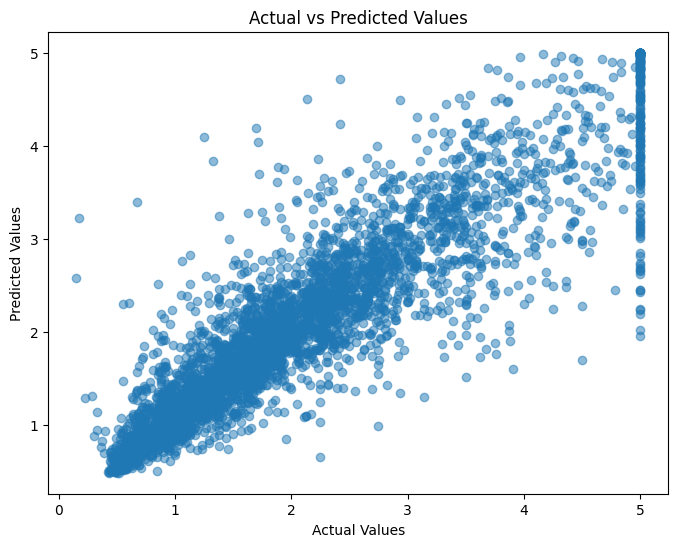

In [23]:
import matplotlib.pyplot as plt

# Прогноз Random Forest

y_pred = rand_forest_reg.predict(X_test)

# Графік
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()